# Attention ablations.

Runs the full study end to end on a Colab GPU.

Runtime type:T4 GPU in Google Colab

The whole study is roughly 10 configurations x 3 seeds. On a T4 with 20,000 training
examples it should take approx 45 to 90 minutes. Start with the `small` run if you
want to see the shape of the results first.

## 1. Install and clone

In [2]:
!git clone https://github.com/StochasticSpirit/attention-ablations.git
%cd attention-ablations
!pip install -q -r requirements.txt

Cloning into 'attention-ablations'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 49 (delta 14), reused 48 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 75.98 KiB | 1.49 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/attention-ablations


## 2. Confirm the implementation is correct

These are the numerical equivalence tests against PyTorch's own attention.

In [3]:
!PYTHONPATH=src python -m pytest tests/ -v --tb=short

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/attention-ablations
configfile: pyproject.toml
plugins: langsmith-0.12.1, anyio-4.14.2, typeguard-4.6.0
collected 47 items                                                             

tests/test_equivalence.py::test_sdpa_matches_torch_functional PASSED     [  2%]
tests/test_equivalence.py::test_sdpa_matches_torch_functional_with_mask PASSED [  4%]
tests/test_equivalence.py::test_sdpa_rows_are_probability_distributions PASSED [  6%]
tests/test_equivalence.py::test_sdpa_masked_positions_receive_no_weight PASSED [  8%]
tests/test_equivalence.py::test_sdpa_scaling_actually_divides_by_sqrt_dk PASSED [ 10%]
tests/test_equivalence.py::test_mha_matches_torch_multiheadattention[1] PASSED [ 12%]
tests/test_equivalence.py::test_mha_matches_torch_multiheadattention[2] PASSED [ 14%]
tests/test_equ

# 3. Check if GPU is being used

In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
device: Tesla T4


## 4. Small run

Uses 1,000 training examples.

In [7]:
!python scripts/run_ablations.py --n-train 1000 --n-val 500 --n-test 500 \
    --epochs 20 --seeds 3 --out results/small

device: cuda

loading data
README.md: 100% 7.81k/7.81k [00:00<00:00, 19.2MB/s]

plain_text/train-00000-of-00001.parquet: downloading bytes: 100% 20.9M/21.0M [00:00<00:00, 38.9MB/s, 1.13MB/s  ]
plain_text/train-00000-of-00001.parquet: downloading bytes: 100% 20.9M/20.9M [00:00<00:00, 28.4MB/s, 2.04MB/s  ]
plain_text/train-00000-of-00001.parquet: reconstructing file: 100% 21.0M/21.0M [00:00<00:00, 28.5MB/s, 2.06MB/s  ]

plain_text/test-00000-of-00001.parquet: downloading bytes:  69% 14.1M/20.5M [00:00<00:00, 32.4MB/s,  373kB/s  ]
plain_text/test-00000-of-00001.parquet: downloading bytes: 100% 20.4M/20.4M [00:00<00:00, 22.4MB/s, 1.98MB/s  ]
plain_text/test-00000-of-00001.parquet: reconstructing file: 100% 20.5M/20.5M [00:00<00:00, 22.5MB/s, 2.00MB/s  ]

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:  44% 18.5M/42.0M [00:00<00:00, 35.8MB/s,  638kB/s  ]
plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:  88% 37.1M/42.0M [00:00<00:00, 60.3MB/s, 2.68MB/s  ]
plain

In [9]:
!cd /content/attention-ablations && zip -r /content/results_small.zip results -x '*.pt'
from google.colab import files
files.download('/content/results_small.zip')

  adding: results/ (stored 0%)
  adding: results/.gitkeep (stored 0%)
  adding: results/smoke/ (stored 0%)
  adding: results/smoke/results.json (deflated 79%)
  adding: results/smoke/training_curves.png (deflated 9%)
  adding: results/smoke/architecture.txt (deflated 90%)
  adding: results/smoke/ablations.png (deflated 19%)
  adding: results/smoke/results_table.md (deflated 57%)
  adding: results/smoke/attention_ranking.txt (deflated 48%)
  adding: results/smoke/attention_heads.png (deflated 25%)
  adding: results/small/ (stored 0%)
  adding: results/small/results.json (deflated 79%)
  adding: results/small/training_curves.png (deflated 8%)
  adding: results/small/architecture.txt (deflated 90%)
  adding: results/small/ablations.png (deflated 19%)
  adding: results/small/results_table.md (deflated 55%)
  adding: results/small/attention_ranking.txt (deflated 64%)
  adding: results/small/attention_heads.png (deflated 19%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
print(open('results/small/results_table.md').read())

| Configuration | Test acc (mean ± std) | Train acc | Gap | Params |
|---|---|---|---|---|
| _majority class_ | 0.5080 | 0.5120 | +0.0040 | 1 |
| _tf-idf + multinomial NB_ | 0.6760 | 0.9450 | +0.2690 | 1 |
| _tf-idf + logistic regression_ | 0.7660 | 0.9780 | +0.2120 | 19,553 |
| _tf-idf bigrams + logistic regression_ | 0.7580 | 0.9930 | +0.2350 | 39,157 |
| | | | | |
| full model | 0.7220 ± 0.0069 | 0.9773 | +0.2553 | 2,771,458 |
| no positional encoding | 0.7087 ± 0.0179 | 0.9463 | +0.2377 | 2,771,458 |
| single head | 0.6807 ± 0.0286 | 0.9380 | +0.2573 | 2,771,458 |
| no feed-forward network | 0.7253 ± 0.0181 | 0.9807 | +0.2553 | 2,639,618 |
| no residual connections | 0.7093 ± 0.0050 | 0.9440 | +0.2347 | 2,771,458 |
| no layer norm | 0.7167 ± 0.0153 | 0.9393 | +0.2227 | 2,770,434 |
| unmasked mean pooling | 0.7133 ± 0.0205 | 0.9650 | +0.2517 | 2,771,458 |
| pre-layer-norm | 0.7347 ± 0.0081 | 0.9627 | +0.2280 | 2,771,714 |
| 1 layer | 0.6987 ± 0.0101 | 0.9517 | +0.2530 | 2,638,978 |


## 5. Data-scaling sweep

Trains the model at 500, 1,000, 2,000, 5,000, 10,000 and 20,000 examples and fits tf-idf
baselines on the same subsets. Reports the crossover point: the training set size at which
the Transformer overtakes the linear model.

Validation and test sets are identical at every training ecamples size. The vocabulary is rebuilt from
each training subset to avoid data leakage.

In [13]:
# Detailed sweep: 6 sizes, 3 seeds.
!python scripts/run_scaling.py --sizes 500 1000 2000 5000 10000 20000 \
    --epochs 30 --seeds 3 --batch-size 64 --out results/scaling

device: cuda
sizes:  [500, 1000, 2000, 5000, 10000, 20000]

loading data
train 20,000 (9954/10046 pos/neg)
val    5,000 (2546/2454 pos/neg)
test  25,000 (12500/12500 pos/neg)
vocab 20,002 

sweeping 6 sizes x 3 seeds
  n=   500  transformer 0.6799 ± 0.0058   best baseline 0.7571 (tf-idf + logistic regression)   margin -0.0773
  n= 1,000  transformer 0.7083 ± 0.0081   best baseline 0.8210 (tf-idf + multinomial NB)   margin -0.1127
  n= 2,000  transformer 0.7395 ± 0.0043   best baseline 0.8336 (tf-idf bigrams + logistic regression)   margin -0.0941
  n= 5,000  transformer 0.7874 ± 0.0044   best baseline 0.8600 (tf-idf bigrams + logistic regression)   margin -0.0726
  n=10,000  transformer 0.8210 ± 0.0028   best baseline 0.8776 (tf-idf bigrams + logistic regression)   margin -0.0565
  n=20,000  transformer 0.8378 ± 0.0035   best baseline 0.8922 (tf-idf bigrams + logistic regression)   margin -0.0544

| Train size | Transformer test acc | Best baseline | Baseline used | Margin |
|---|---|-

### The scaling curve and the crossover point

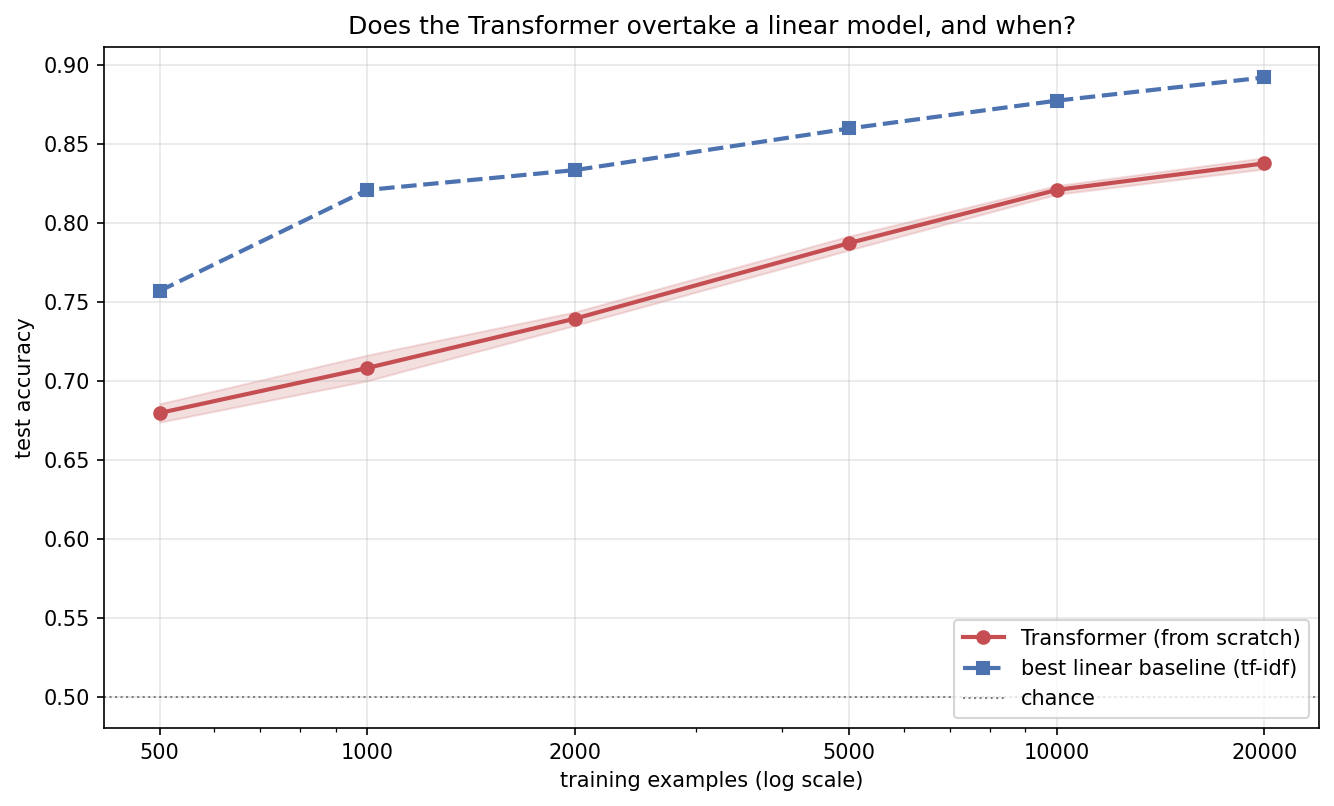

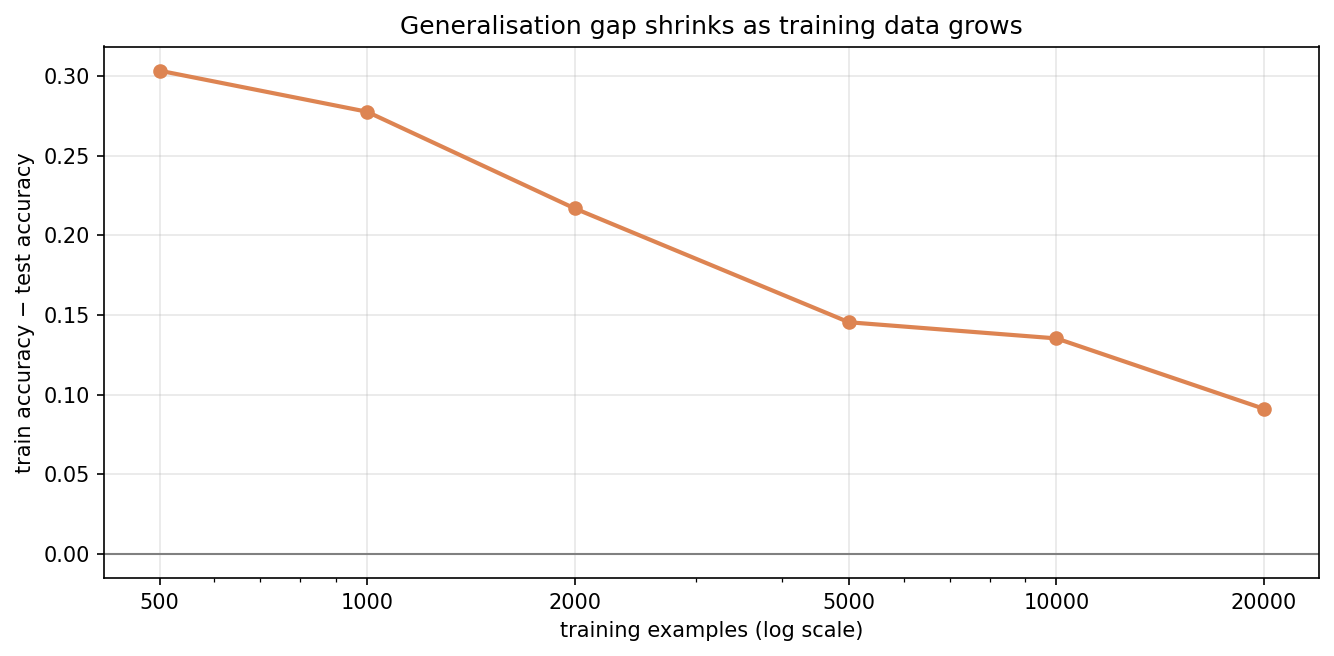

| Train size | Transformer test acc | Best baseline | Baseline used | Margin |
|---|---|---|---|---|
| 500 | 0.6799 ± 0.0058 | 0.7571 | tf-idf + logistic regression | -0.0773 − |
| 1,000 | 0.7083 ± 0.0081 | 0.8210 | tf-idf + multinomial NB | -0.1127 − |
| 2,000 | 0.7395 ± 0.0043 | 0.8336 | tf-idf bigrams + logistic regression | -0.0941 − |
| 5,000 | 0.7874 ± 0.0044 | 0.8600 | tf-idf bigrams + logistic regression | -0.0726 − |
| 10,000 | 0.8210 ± 0.0028 | 0.8776 | tf-idf bigrams + logistic regression | -0.0565 − |
| 20,000 | 0.8378 ± 0.0035 | 0.8922 | tf-idf bigrams + logistic regression | -0.0544 − |

**No crossover found.** The Transformer did not overtake the best linear baseline at any size up to 20,000. On this task, with this architecture and no pretraining, the linear model is the better choice across the whole range swept.


In [15]:
from IPython.display import Image, display

display(Image("results/scaling/scaling_curve.png"))
display(Image("results/scaling/scaling_gap.png"))
print(open("results/scaling/scaling_table.md").read())

## 6. The full ablation run

Runs on 20,000 training examples, the full 25,000 example test set, 3 seeds per configuration.

In [16]:
!python scripts/run_ablations.py --n-train 20000 --n-val 5000 --n-test 25000 \
    --epochs 30 --seeds 3 --batch-size 64 --out results/full

device: cuda

loading data
train 20,000 (9954/10046 pos/neg)
val    5,000 (2546/2454 pos/neg)
test  25,000 (12500/12500 pos/neg)
vocab 20,002 

module                                      shape                         params
--------------------------------------------------------------------------------
embedding.weight                            20002x128                  2,560,256
blocks.0.self_attn.w_q.weight               128x128                       16,384
blocks.0.self_attn.w_q.bias                 128                              128
blocks.0.self_attn.w_k.weight               128x128                       16,384
blocks.0.self_attn.w_k.bias                 128                              128
blocks.0.self_attn.w_v.weight               128x128                       16,384
blocks.0.self_attn.w_v.bias                 128                              128
blocks.0.self_attn.w_o.weight               128x128                       16,384
blocks.0.self_attn.w_o.bias                 12

## 7. Ablation figures

ablations.png


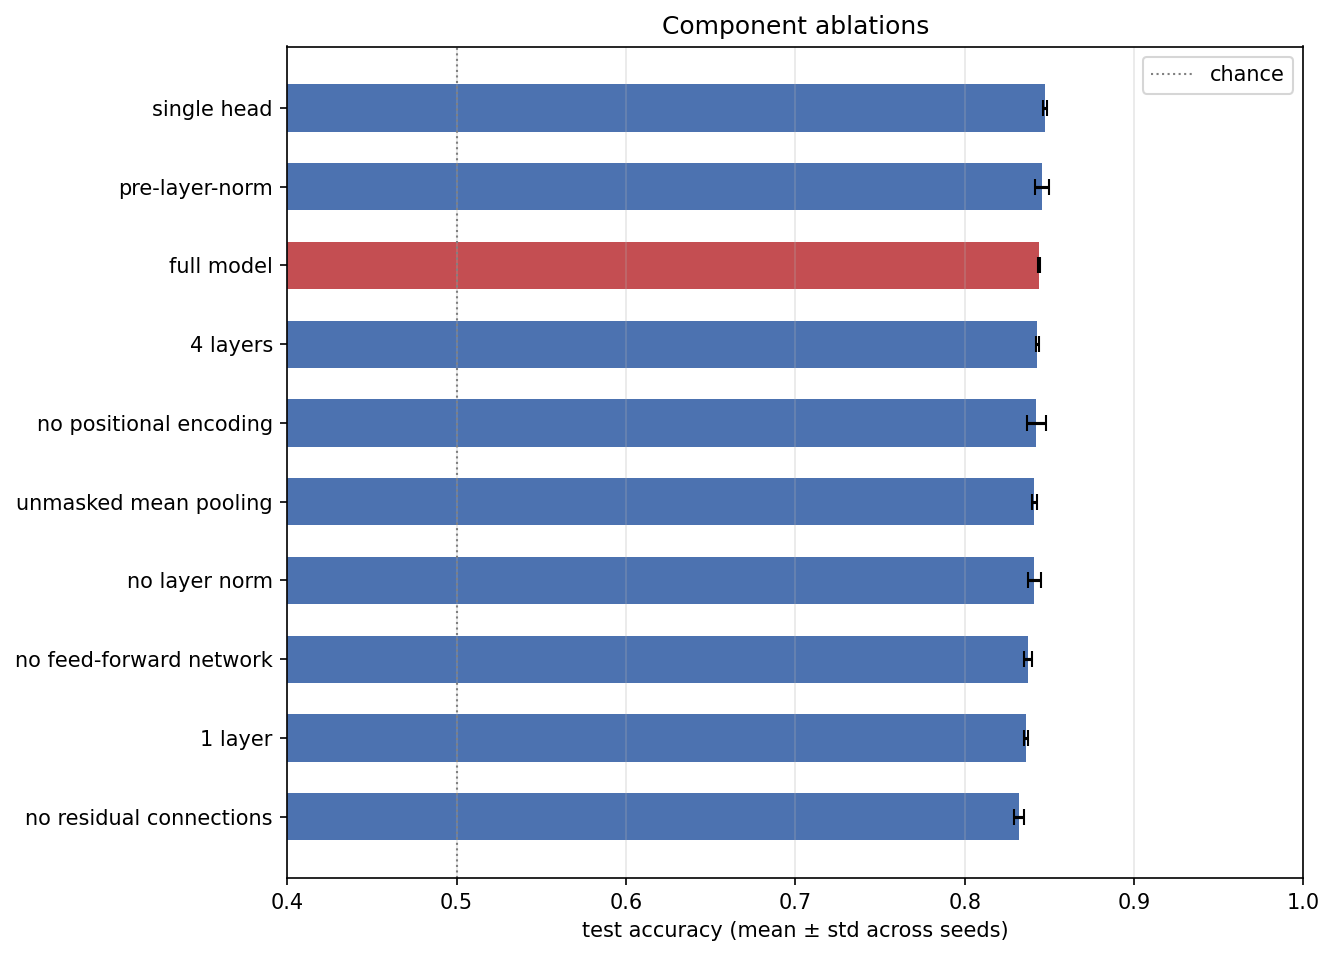

training_curves.png


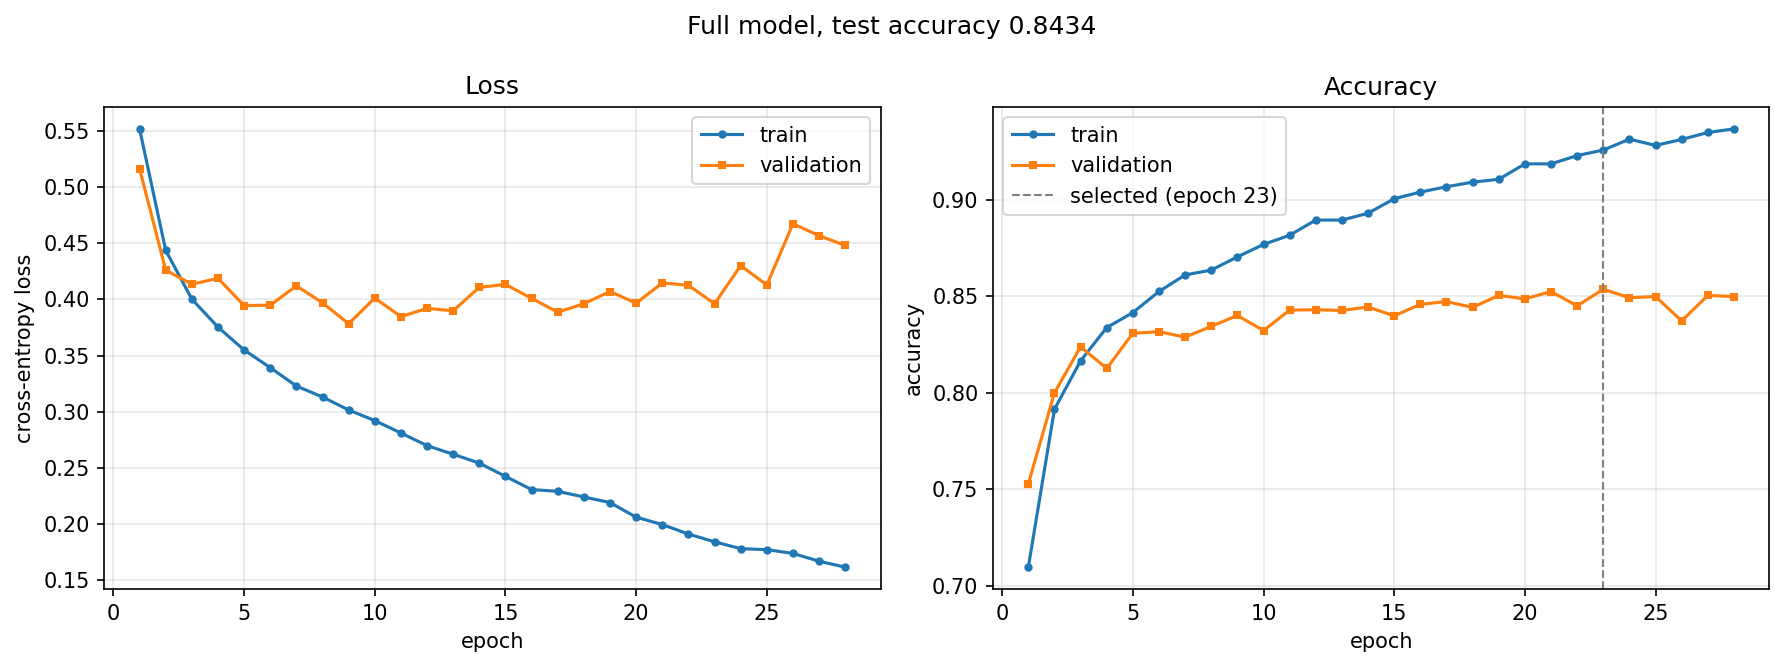

attention_heads.png


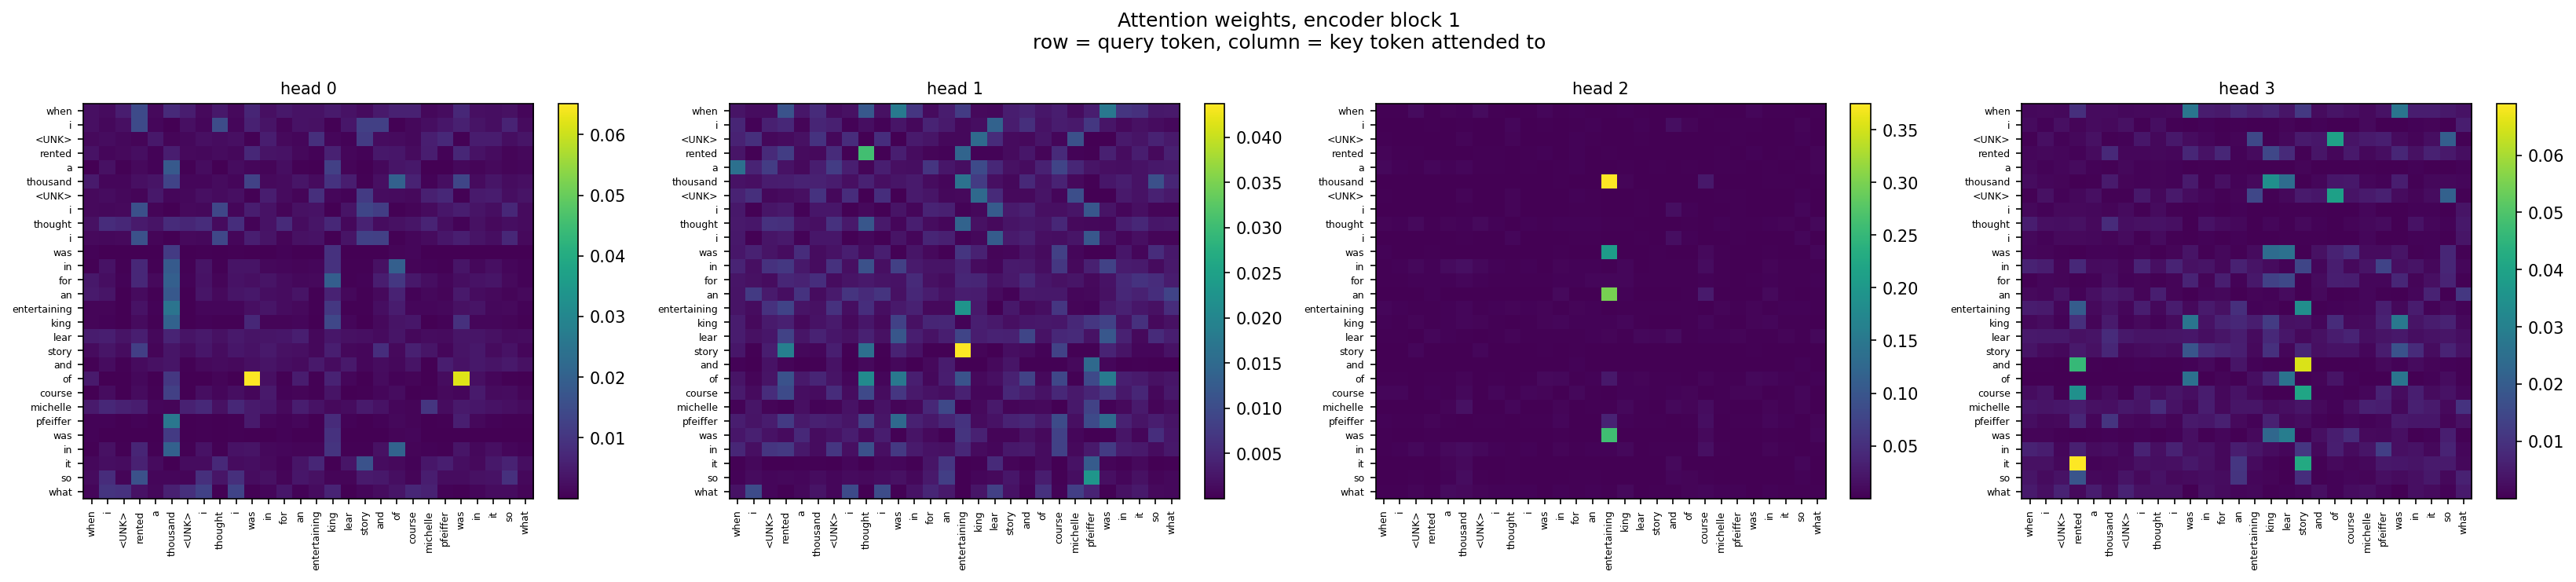

In [17]:
from IPython.display import Image, display
from pathlib import Path

run = Path("results/full")
for name in ["ablations.png", "training_curves.png", "attention_heads.png"]:
    path = run / name
    if path.exists():
        print(name)
        display(Image(str(path)))

## 8. Ablation table

In [18]:
print(open("results/full/results_table.md").read())

| Configuration | Test acc (mean ± std) | Train acc | Gap | Params |
|---|---|---|---|---|
| _majority class_ | 0.5000 | 0.5023 | +0.0023 | 1 |
| _tf-idf + multinomial NB_ | 0.8333 | 0.8975 | +0.0642 | 1 |
| _tf-idf + logistic regression_ | 0.8824 | 0.9281 | +0.0457 | 20,001 |
| _tf-idf bigrams + logistic regression_ | 0.8922 | 0.9406 | +0.0484 | 40,001 |
| | | | | |
| full model | 0.8440 ± 0.0006 | 0.9526 | +0.1086 | 2,825,474 |
| no positional encoding | 0.8423 ± 0.0056 | 0.9535 | +0.1111 | 2,825,474 |
| single head | 0.8475 ± 0.0011 | 0.9452 | +0.0977 | 2,825,474 |
| no feed-forward network | 0.8373 ± 0.0025 | 0.9506 | +0.1133 | 2,693,634 |
| no residual connections | 0.8320 ± 0.0032 | 0.9114 | +0.0795 | 2,825,474 |
| no layer norm | 0.8410 ± 0.0039 | 0.9055 | +0.0645 | 2,824,450 |
| unmasked mean pooling | 0.8410 ± 0.0013 | 0.9613 | +0.1203 | 2,825,474 |
| pre-layer-norm | 0.8457 ± 0.0040 | 0.9654 | +0.1197 | 2,825,730 |
| 1 layer | 0.8361 ± 0.0014 | 0.9387 | +0.1026 | 2,692,994 |


## 9. Which tokens the model actually attends to
In the initial model notebook we found that heads focus on sentiment-bearing words. We recheck that claim here.

In [19]:
print(open("results/full/attention_ranking.txt").read())

Tokens receiving the most attention (mean over heads and queries):

  oh                  0.0150
  cover               0.0150
  entertaining        0.0135
  also                0.0134
  fighting            0.0129
  then                0.0122
  involved            0.0097
  go                  0.0095
  myself              0.0087
  quickly             0.0084
  others              0.0081
  effect              0.0078


## 10. Were the baselines getting an unfair advantage?

The Transformer only reads the first 256 tokens of a review. The tf-idf baselines read the whole text, because `run_baselines` works on the untruncated token lists. 
A good number of IMDB reviews run past 256 tokens, so part of the 4.8 point gap at 20,000 training examples could be the baselines seeing more text than the Transformer.

I tested it by truncating the baselines' input to the same 256 tokens and refitting. I fel that if the gap held up, it could indicate a real difference between the two model classes and if it collapsed, the headline number was likely measuring my preprocessing.

Truncation costs the best baseline 1.5 points, which leaves 3.3 points of the original 4.8. So the linear model still wins on equal footing.

(This cell was run in a later session, so its execution count is lower than the cells above.)

In [8]:
import sys, os
os.chdir('/content/attention-ablations')
sys.path.insert(0, 'src')

from attnablate.data import load_imdb
from attnablate.baselines import run_baselines
import copy

corpus = load_imdb(n_train=20000, n_val=5000, n_test=25000)
truncated = copy.copy(corpus)
truncated.train_tokens = [t[:256] for t in corpus.train_tokens]
truncated.val_tokens   = [t[:256] for t in corpus.val_tokens]
truncated.test_tokens  = [t[:256] for t in corpus.test_tokens]

for r in run_baselines(truncated):
    print(f"{r.name:<40} {r.test_acc:.4f}")

majority class                           0.5000
tf-idf + multinomial NB                  0.8252
tf-idf + logistic regression             0.8696
tf-idf bigrams + logistic regression     0.8770
